# **Section 2: CNV Feature Selection**

This notebook imports the CNV feature matrix, merges it with the metadata containing the resistance profile of each strain and performs feature selection. 

**Overview:**
1. Load cnv data and resistance phenotypes
2. Merge data on sample name
3. Remove duplicate features (identical across all samples)
4. Select features associated with resistance (chi-square test)
9. Save cleaned feature matrix ready for ML

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler

# Set pastel color palette for plots
sns.set_palette("pastel")

In [3]:
# Select antibiotic
target_antibiotic = 'SXT'

# Define paths:
cnv_tsv = "cnv_filtered.tsv"
resistance_profiles = "../genome_metadata.csv"

## **0. Helper functions**
The function **parse_resistance_profile** is used to extract the resistance profiles from the genome_metadata.csv file.

In [4]:
def parse_resistance_profile(profile_str):
    """
    Parse resistance profile string into individual antibiotic phenotypes.

    Current format: "Resistant to X, Y; Susceptible to A, B; Intermediate to C; Not determined: D"
    Returns: dict with antibiotic: phenotype (R/S/I/ND)
    """
    phenotypes = {}
    
    if pd.isna(profile_str):
        return phenotypes
    
    # Split by semicolon to get phenotype groups
    parts = str(profile_str).split(';')
    
    for part in parts:
        part = part.strip()
        if not part:
            continue
            
        # Determine phenotype
        if part.startswith('Resistant to'):
            phenotype = 'R'
            antibiotics_str = part.replace('Resistant to', '').strip()
        elif part.startswith('Susceptible to'):
            phenotype = 'S'
            antibiotics_str = part.replace('Susceptible to', '').strip()
        elif part.startswith('Intermediate to'):
            phenotype = 'I'
            antibiotics_str = part.replace('Intermediate to', '').strip()
        elif part.startswith('Not determined'):
            phenotype = 'ND'
            antibiotics_str = part.replace('Not determined:', '').strip()
        else:
            continue
        
        # Split antibiotics by comma and add to dict
        antibiotics = [ab.strip() for ab in antibiotics_str.split(',')]
        for antibiotic in antibiotics:
            if antibiotic:
                phenotypes[antibiotic] = phenotype
    
    return phenotypes

## **1. Load and preprocess the data**
We first want to load the feature matrix (containing detected SNPs for all the strains) and a metadata file containing the resistance profile for all strains. 
We will then make sure that the strains in the feature matrix have a corresponding resistance profile.

### **1.1 Load CNV feature matrix and resistance profiles**

In [5]:
# Load SNP feature matrix (rows = samples, columns = SNPs)
cnv_df = pd.read_csv(cnv_tsv, sep='\t', index_col=0)
print(f"SNP feature matrix shape: {cnv_df.shape}")
cnv_df.head()

SNP feature matrix shape: (221, 23338)


,cnv_depth__IBNLCO_00001__IBNLCO_00001__gene,cnv_depth__unknown__unknown__source,cnv_depth__IBNLCO_00001__Putative__CDS,cnv_depth__IBNLCO_00001__IBNLCO_00001__gene__promoter,cnv_depth__IBNLCO_00001__Putative__CDS__promoter,cnv_depth__IBNLCO_00002__IBNLCO_00002__gene,cnv_depth__IBNLCO_00002__Cation/H+__CDS,cnv_depth__IBNLCO_00002__Cation/H+__CDS__promoter,cnv_depth__IBNLCO_00002__IBNLCO_00002__gene__promoter,cnv_depth__IBNLCO_00003__tRNA__CDS,...,cnv_depth__IBNLCO_05853__IBNLCO_05853__gene,cnv_depth__IBNLCO_05853__Nucleoid__CDS,cnv_depth__IBNLCO_05854__IBNLCO_05854__gene,cnv_depth__IBNLCO_05854__Initiator__CDS,cnv_depth__IBNLCO_05854__IBNLCO_05854__gene__promoter,cnv_depth__IBNLCO_05854__Initiator__CDS__promoter,cnv_depth__IBNLCO_05855__IBNLCO_05855__gene,cnv_depth__IBNLCO_05855__hypothetical__CDS,cnv_depth__IBNLCO_05855__IBNLCO_05855__gene__promoter,cnv_depth__IBNLCO_05855__hypothetical__CDS__promoter
sample,,,,,,,,,,,,,,,,,,,,,
SRR3404582,0.456210,-0.064161,0.456210,0.344561,0.344561,0.072854,0.072854,0.546083,0.546083,0.267388,...,-0.373267,-0.373267,0.143766,0.143766,0.353816,0.353816,0.770642,0.770642,0.328191,0.328191
SRR3404597,0.501361,-0.049432,0.501361,0.319320,0.319320,0.189164,0.189164,0.541349,0.541349,0.287937,...,-0.406352,-0.406352,-0.099969,-0.099969,0.122482,0.122482,0.441589,0.441589,-0.101593,-0.101593
SRR3404599,0.456717,-0.061306,0.456717,0.262671,0.262671,0.119334,0.119334,0.530473,0.530473,0.208922,...,-0.368799,-0.368799,0.014885,0.014885,0.287339,0.287339,0.731126,0.731126,0.359241,0.359241
SRR5927082,0.365460,-0.097766,0.365460,0.188572,0.188572,0.207752,0.207752,0.505214,0.505214,-0.047895,...,-0.334186,-0.334186,0.066785,0.066785,0.169225,0.169225,0.117027,0.117027,-0.709921,-0.709921
SRR6075123,0.481897,-0.087126,0.481897,0.484432,0.484432,0.209904,0.209904,0.319695,0.319695,0.170319,...,-0.048866,-0.048866,0.027058,0.027058,0.120249,0.120249,0.506042,0.506042,-0.061710,-0.061710


In [6]:
# Load resistance profiles
resistances = pd.read_csv(resistance_profiles)
print(f"Sample metadata shape: {resistances.shape}")
resistances.head()

Sample metadata shape: (283, 5)


,genome_name,source,species,resistance_profile,sra_accession
0,EPAC004,Patient,B. pseudomallei,"Resistant to SXT; Susceptible to AMC, CAZ; Not...",SRR27387708
1,EPAC006,Patient,B. pseudomallei,"Resistant to SXT; Susceptible to AMC, CAZ, IPM",SRR27387706
2,EPAC013,Patient,B. pseudomallei,"Resistant to SXT; Susceptible to AMC, CAZ, IPM",SRR27387705
3,EPAC021,Patient,B. pseudomallei,"Resistant to SXT; Susceptible to AMC, CAZ, IPM",SRR27387702
4,EPAC023,Patient,B. pseudomallei,"Resistant to SXT; Susceptible to AMC, CAZ, IPM",SRR27387701


### **1.2 Parse resistance profiles**
We will now parse the resistance profiles into a dictionary using the function parse_resistance_profile defined above. 
The list of dictionaries is then converted into a data frame which contains resistance information for each sample.

In [7]:
# Parse resistance profiles into a dictionary with antibiotic phenotypes
parsed_resistances = resistances['resistance_profile'].apply(parse_resistance_profile)
print(f"\nDictionary list structure: \n")
print(parsed_resistances.head())

# Convert list of dictionaries into a DataFrame
resistances_df = pd.json_normalize(parsed_resistances)
print(f"\nResistance data frame structure: \n")
print(resistances_df.head())

# Add sample name (sra_accession) to data frame and set is as index
resistances_df['sra_accession'] = resistances['sra_accession'].values
resistances_df = resistances_df.set_index('sra_accession')

print(f"\nResistance data frame shape: {resistances_df.shape}")


Dictionary list structure: 

0    {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'ND'}
1     {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
2     {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
3     {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
4     {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
Name: resistance_profile, dtype: object

Resistance data frame structure: 

  SXT AMC CAZ IPM  MEM   TZ TMEM/SMX
0   R   S   S  ND  NaN  NaN      NaN
1   R   S   S   S  NaN  NaN      NaN
2   R   S   S   S  NaN  NaN      NaN
3   R   S   S   S  NaN  NaN      NaN
4   R   S   S   S  NaN  NaN      NaN

Resistance data frame shape: (283, 7)


### **1.3 Find common samples between feature matrix and resistance profiles**
Let's now filter the SNP feature matrix and the resistance profile data frames so that they only contain common samples

In [8]:
# Find common samples between SNP data and resistance profile data and keep only common samples
# Start by removing duplicate entries
resistances_df = resistances_df.loc[~resistances_df.index.duplicated(keep='first')]
cnv_df = cnv_df.loc[~cnv_df.index.duplicated(keep='first')]

# Find common samples
common_samples = cnv_df.index.intersection(resistances_df.index)
print(f"\nCommon samples: {len(common_samples)} out of {len(cnv_df)} CNV samples and {len(resistances_df)} samples with known resistance profiles")

# Keep only samples with both SNP and phenotype data
cnv_df = cnv_df.loc[common_samples]
resistances_df = resistances_df.loc[common_samples]

print(f"\nMerged data shape:")
print(f"SNPs: {cnv_df.shape}")
print(f"Resistance profiles: {resistances_df.shape}")


Common samples: 221 out of 221 CNV samples and 262 samples with known resistance profiles

Merged data shape:
SNPs: (221, 23338)
Resistance profiles: (221, 7)


### **1.4 Filter feature matrix according to resistance profile**
Let's now go back to our feature matrix and make sure all samples have valid information for the SXT antibiotic. I will also create a binary category for that antibiotic (Susceptible = 0, Resistant = 1).

In [9]:
# Create binary target: S=0 (susceptible), R=1 (resistant)
SXT_profile = resistances_df[target_antibiotic].copy()

# Remove ND 
valid_samples = SXT_profile[SXT_profile.isin(['S', 'R'])].index
print(f"Valid samples: {len(valid_samples)} out of {len(SXT_profile)}")

# Filter feature matrix
cnv_df = cnv_df.loc[valid_samples]

# Convert resistance profile to int (1=Resistant, 0=Susceptible)
SXT_profile = (SXT_profile.loc[valid_samples] == 'R').astype(int) 

print(f"\nFinal dataset:")
print(f"Samples: {len(cnv_df)}")
print(f"CNV: {cnv_df.shape[1]}")
print(f"\nSXT resistance distribution:\n{SXT_profile.value_counts()}")

Valid samples: 221 out of 221

Final dataset:
Samples: 221
CNV: 23338

SXT resistance distribution:
SXT
1    119
0    102
Name: count, dtype: int64


## **2. Feature Selection**
Now that we have our feature matrix and the resistance profile for all of the strains, let's perform some preliminary data cleaning on the feature matrix. 

### **2.1. Remove Duplicate Features**
I will start by removing duplicated features.

In [10]:
# Find duplicate SNPs
cnv_T = cnv_df.T
duplicates = cnv_T.duplicated(keep='first')

print(f"Number of duplicated features: {duplicates.sum()}")

# Remove duplicate SNPs
cnv_unique = cnv_df.loc[:, ~duplicates].copy()

print(f"\nAfter removing duplicates:")
print(f"  features before: {cnv_df.shape[1]}")
print(f"  features after: {cnv_unique.shape[1]}")
print(f"  removed: {cnv_df.shape[1] - cnv_unique.shape[1]} SNPs")

Number of duplicated features: 11619

After removing duplicates:
  features before: 23338
  features after: 11719
  removed: 11619 SNPs


We see that a lot of the features were duplications of each other. This comes from how the cnv matrix is created and how GenBank annotations are created. There typically is an annotation for the whole **gene** region and an nearly identical annotation for the **coding sequence (CDS)**. This type of region annotation thus creates nearly identical features (especiall in bacteria where gene and coding regions are typically almost identical). 

### **2.2 Removing Highly Correlated Features**
I will set a threshold and remove any feature that has a correlation above 99% with another SNP. I will always remove the SNP that has the least variance in a correlated pair. Highly correlated features do not provide much additional information for a machine learning algorithm. 

In [11]:
print(f"Computing feature correlations for {len(cnv_unique.columns)} CNVs")
print("(Processing in batches to avoid memory issues)")

high_corr_pairs = []
cnv_array = cnv_unique.values.astype(np.float32)
n_cnv = cnv_array.shape[1]

# Process in batches
batch_size = 500
for batch_start in range(0, n_cnv, batch_size):
    batch_end = min(batch_start + batch_size, n_cnv)
    
    # Compute correlations for this batch against all SNPs
    batch = cnv_array[:, batch_start:batch_end]
    
    # Normalize for correlation calculation
    batch_mean = batch.mean(axis=0, keepdims=True)
    batch_std = batch.std(axis=0, keepdims=True)
    batch_norm = (batch - batch_mean) / (batch_std + 1e-10)
    
    # Full array normalized
    all_mean = cnv_array.mean(axis=0, keepdims=True)
    all_std = cnv_array.std(axis=0, keepdims=True)
    all_norm = (cnv_array - all_mean) / (all_std + 1e-10)
    
    # Correlation = dot product of normalized data / n_samples
    corr = np.abs(np.dot(batch_norm.T, all_norm) / len(cnv_array))
    
    # Find pairs above threshold (only above diagonal)
    for i, cnv_i_idx in enumerate(range(batch_start, batch_end)):
        for j in range(cnv_i_idx + 1, n_cnv):
            if corr[i, j] > 0.99:
                high_corr_pairs.append((
                    cnv_unique.columns[cnv_i_idx],
                    cnv_unique.columns[j],
                    float(corr[i, j])
                ))
    
    if (batch_end) % 2000 == 0 or batch_end == n_cnv:
        print(f"  Processed {batch_end}/{n_cnv} Features. ({len(high_corr_pairs)} pairs found so far)")

print(f"\nTotal highly correlated pairs (r > 0.99): {len(high_corr_pairs)}")

if len(high_corr_pairs) > 0:
    print(f"\nFirst 10 correlated pairs:")
    for cnv1, cnv2, corr in high_corr_pairs[:10]:
        print(f"{cnv1} <-> {cnv2}: r={corr:.4f}")

Computing feature correlations for 11719 CNVs
(Processing in batches to avoid memory issues)
  Processed 2000/11719 Features. (193 pairs found so far)
  Processed 4000/11719 Features. (6090 pairs found so far)
  Processed 6000/11719 Features. (6869 pairs found so far)
  Processed 8000/11719 Features. (7932 pairs found so far)
  Processed 10000/11719 Features. (7964 pairs found so far)
  Processed 11719/11719 Features. (7993 pairs found so far)

Total highly correlated pairs (r > 0.99): 7993

First 10 correlated pairs:
cnv_depth__IBNLCO_00021__IBNLCO_00021__gene__promoter <-> cnv_depth__IBNLCO_00020__IBNLCO_00020__gene__promoter: r=1.0000
cnv_depth__IBNLCO_00086__IBNLCO_00086__gene__promoter <-> cnv_depth__IBNLCO_00085__Transmembrane__CDS__promoter: r=0.9901
cnv_depth__IBNLCO_00089__Catechol__CDS__promoter <-> cnv_depth__IBNLCO_00090__Betaproteobacteria_toxic_sRNA__gene: r=0.9903
cnv_depth__IBNLCO_00091__IBNLCO_00091__gene <-> cnv_depth__IBNLCO_00090__Betaproteobacteria_toxic_sRNA__gene

In [ ]:
# LD pruning. For each correlated pair, keep only one snp. 
features_to_remove = set()

for cnv1, cnv2, corr in high_corr_pairs:
    # Simple strategy: remove the one with lower variance
    var1 = cnv_unique[cnv1].var()
    var2 = cnv_unique[cnv2].var()
    
    if var1 < var2:
        features_to_remove.add(cnv1)
    else:
        features_to_remove.add(cnv2)

# Remove correlated SNPs
cnv_uncorr = cnv_unique.loc[:, ~cnv_unique.columns.isin(features_to_remove)].copy()

print(f"After LD pruning:")
print(f"  Features before: {cnv_unique.shape[1]}")
print(f"  Features after: {cnv_uncorr.shape[1]}")
print(f"  Removed: {len(features_to_remove)} features due to high correlation")

After LD pruning:
  SNPs before: 11719
  SNPs after: 11218
  Removed: 501 features due to high correlation


### **2.3 Select only features correlated with resistance**
I will now filter the feature matrix to keep only features that are correlated with the resistance profile. Other features are likely not very informative for a machine learning algorithm. 

To do so, I will use Spearman's correlation to see if the feature is correlated with resistance. I will the only keep features that a significantly associated with the resistance profile (p-value < 0.1)

#### **2.3.1 Calculate correlations and p-values**

In [34]:
p_values = []
spearman_r = []
effect_sizes = []
feature_names = []

for cnv in cnv_uncorr.columns:
    # Spearman correlation
    r, p_val = spearmanr(cnv_uncorr[cnv], SXT_profile)
    p_values.append(p_val)
    spearman_r.append(r)
    feature_names.append(cnv)
    
    # Effect size: calculate Cohen's d
    resistant = cnv_uncorr[cnv][SXT_profile == 1]
    susceptible = cnv_uncorr[cnv][SXT_profile == 0]
    
    mean_diff = resistant.mean() - susceptible.mean()
    pooled_std = np.sqrt((resistant.std()**2 + susceptible.std()**2) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
    effect_sizes.append(cohens_d)

# Multiple testing correction (Benjamini-Hochberg)
rejected, p_adj, _, _ = multipletests(p_values, method='fdr_bh')

# Create results dataframe
correlation_results = pd.DataFrame({
    'cnv_feature': feature_names,
    'spearman_r': spearman_r,
    'p_value': p_values,
    'p_value_adj': p_adj,
    'cohens_d': effect_sizes,
    'significant_fdr': rejected
})

# Sort by p-value
correlation_results = correlation_results.sort_values('p_value')

print(f"Total CNV features: {len(correlation_results)}")
print(f"Significant after FDR correction (q<0.05): {correlation_results['significant_fdr'].sum()}\n")

print("Top 20 associated CNV features:")
print(correlation_results.head(20)[['cnv_feature', 'spearman_r', 'p_value', 'cohens_d']].to_string())

/tmp/ipykernel_162042/898081159.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p_val = spearmanr(cnv_uncorr[cnv], SXT_profile)


Total CNV features: 11218
Significant after FDR correction (q<0.05): 7882

Top 20 associated CNV features:
                                                   cnv_feature  spearman_r       p_value  cohens_d
150                        cnv_depth__IBNLCO_00076__dnaA__gene    0.748510  6.091091e-41  1.860899
610      cnv_depth__IBNLCO_00312__IBNLCO_00312__gene__promoter    0.721762  7.476144e-37  1.947325
6447               cnv_depth__IBNLCO_03389__IBNLCO_03389__gene    0.706254  1.076474e-34  1.473706
5664               cnv_depth__IBNLCO_02981__IBNLCO_02981__gene    0.696864  1.869301e-33  1.109355
5879           cnv_depth__IBNLCO_03094__Protein__CDS__promoter    0.695014  3.237612e-33  1.696318
3291               cnv_depth__IBNLCO_01722__Syringopeptin__CDS   -0.693165  5.584283e-33 -1.825139
6128                         cnv_depth__IBNLCO_03222__DNA__CDS    0.686620  3.719664e-32  1.603154
8826                      cnv_depth__IBNLCO_04643__Linear__CDS   -0.683490  9.051967e-32 -1.574308
14

#### **2.3.2 Visualize the correlations**

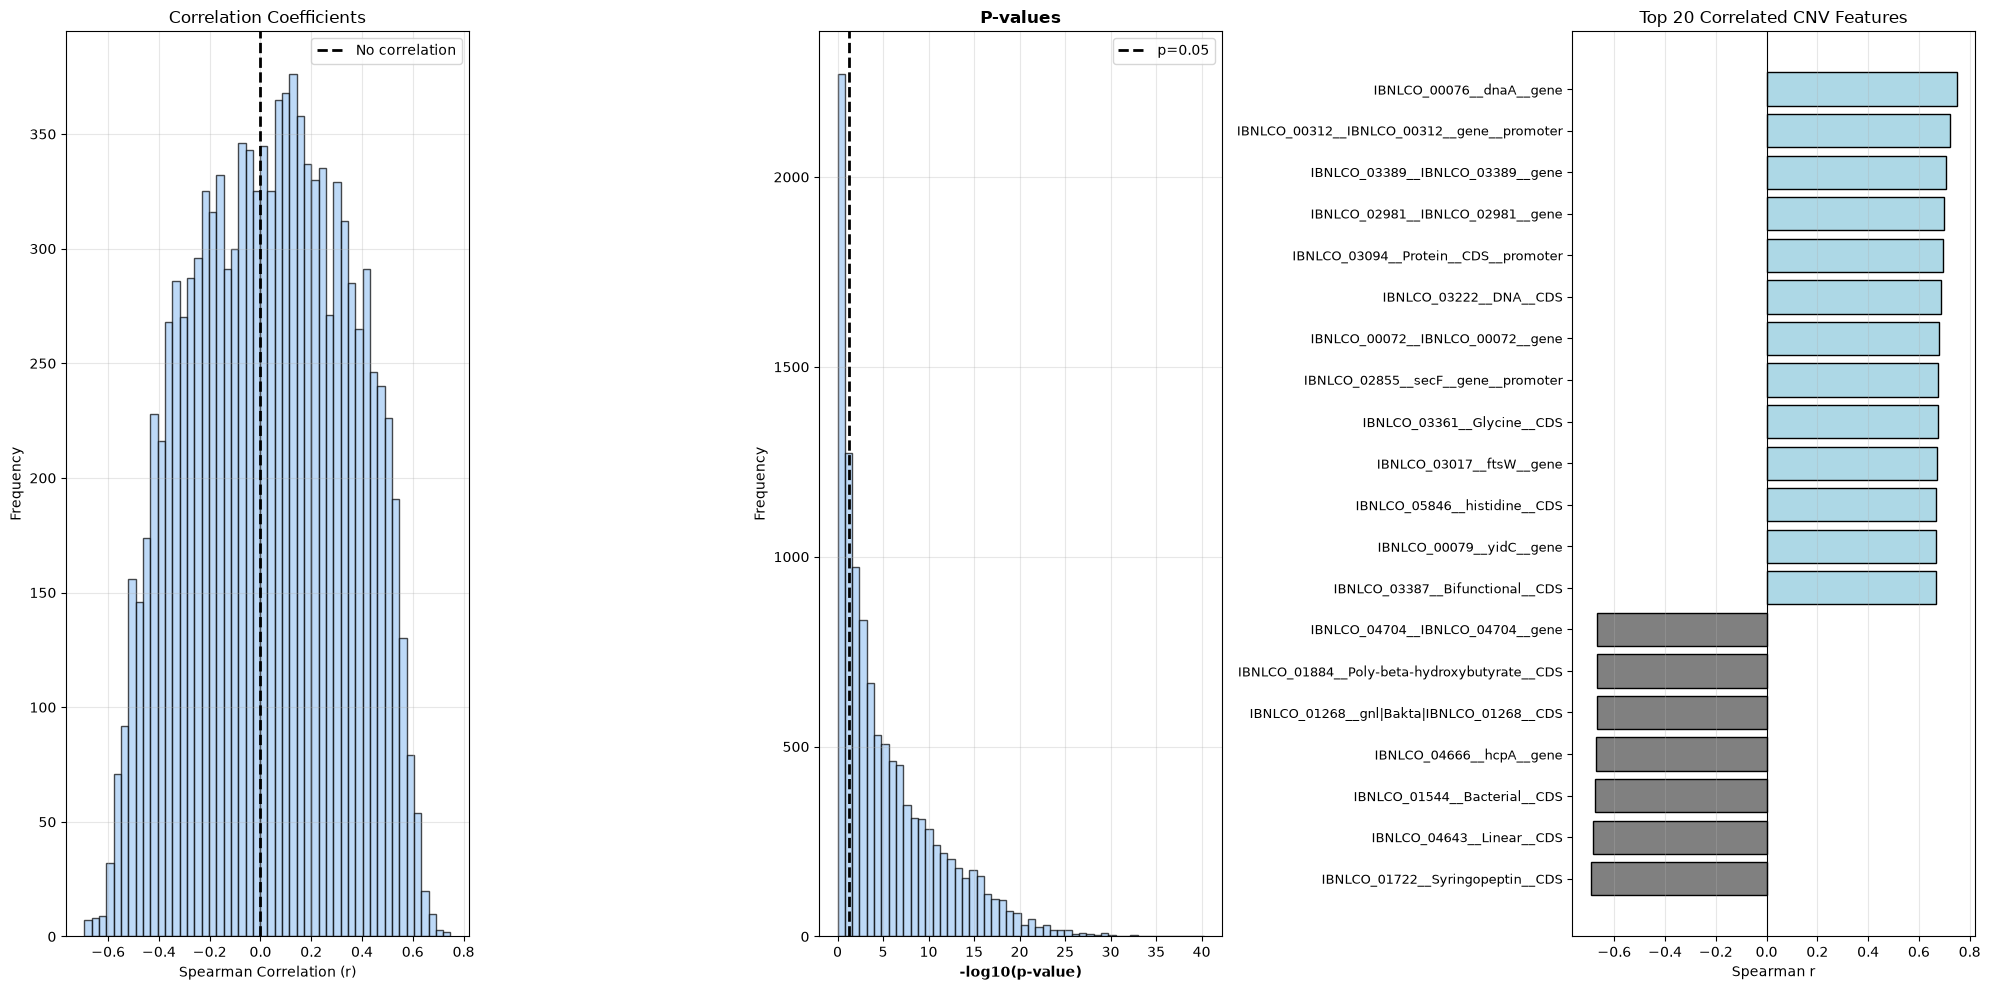

In [35]:
# Visualize top features
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# 1. Distribution of Spearman r values
ax = axes[0]
ax.hist(correlation_results['spearman_r'], bins=50, alpha=0.7, edgecolor="black")
ax.axvline(0, color="black", linestyle='--', linewidth=2, label="No correlation")
ax.set_xlabel("Spearman Correlation (r)")
ax.set_ylabel("Frequency")
ax.set_title("Correlation Coefficients")
ax.legend()
ax.grid(alpha=0.3)

# 2. P-value distribution
ax = axes[1]
ax.hist(-np.log10(correlation_results['p_value']), bins=50, alpha=0.7, edgecolor="black")
ax.axvline(-np.log10(0.05), color="black", linestyle='--', linewidth=2, label='p=0.05')
ax.set_xlabel("-log10(p-value)", fontweight='bold')
ax.set_ylabel("Frequency")
ax.set_title("P-values", fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 3. Top 20 features
ax = axes[2]
top10 = correlation_results.head(20).sort_values('spearman_r')
colors = ["lightblue" if x > 0 else "grey" for x in top10['spearman_r']]
bars = ax.barh(range(len(top10)), top10['spearman_r'], color=colors, edgecolor='black', linewidth=1)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels([f.replace("cnv_depth__", "") for f in top10['cnv_feature']], fontsize=9)
ax.set_xlabel("Spearman r")
ax.set_title("Top 20 Correlated CNV Features")
ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("cnv_univariate_selection.png", dpi=300, bbox_inches='tight')
plt.show()

# Save results
correlation_results.to_csv("univariate_feature_selection.csv", index=False)

/tmp/ipykernel_162042/1174421989.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_162042/1174421989.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_162042/1174421989.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_162042/1174421989.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_162042/1174421989.py:

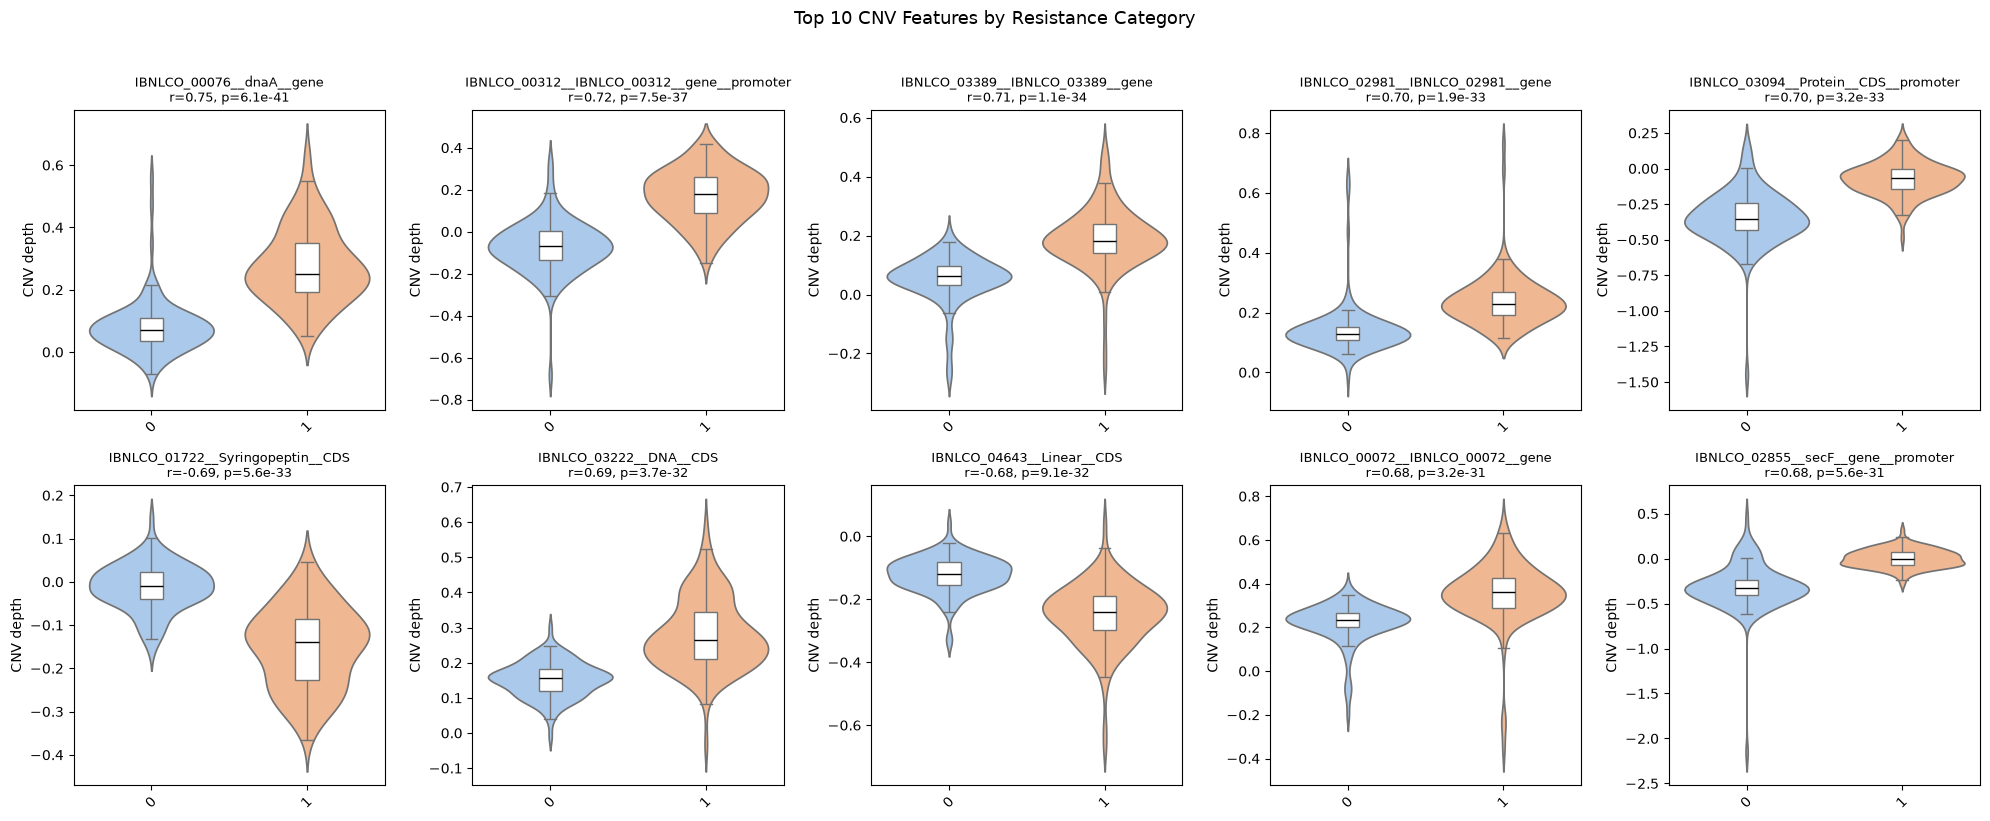

In [32]:
# Boxplot/violin of top-N features by class label
top_n = 10
top_features = correlation_results.head(top_n)['cnv_feature'].tolist()

n_cols = 5
n_rows = int(np.ceil(top_n / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Combine CNV data with category labels
plot_df = cnv_uncorr.copy()
plot_df['SXT_profile'] = SXT_profile.values if hasattr(SXT_profile, 'values') else SXT_profile


for i, feature in enumerate(top_features):
    ax = axes[i]
    sns.violinplot(
        data=plot_df, x='SXT_profile', y=feature, ax=ax,
        inner=None, palette='pastel'
    )
    sns.boxplot(
        data=plot_df, x='SXT_profile', y=feature, ax=ax,
        width=0.15, showcaps=True, boxprops={'zorder': 2, 'facecolor': 'white'},
        whiskerprops={'zorder': 2}, medianprops={'color': 'black', 'zorder': 3},
        showfliers=False
    )
    
    r = correlation_results.loc[correlation_results['cnv_feature'] == feature, 'spearman_r'].values[0]
    p = correlation_results.loc[correlation_results['cnv_feature'] == feature, 'p_value'].values[0]
    
    ax.set_title(f"{feature.replace('cnv_depth__', '')}\nr={r:.2f}, p={p:.1e}", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("CNV depth")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle(f"Top {top_n} Features by Resistance Category", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("cnv_top_features_by_category.png", dpi=300, bbox_inches='tight')
plt.show()

#### **2.3.3 Filter the data**

In [39]:
# Filter by significance (p < 0.05)
significant_cnvs = correlation_results[correlation_results['p_value'] < 0.05]['cnv_feature'].values

print(f"Significant CNVs (p < 0.05): {len(significant_cnvs)} out of {cnv_uncorr.shape[1]} ({len(significant_cnvs)/cnv_uncorr.shape[1]*100:.1f}%)")

# Keep only significant SNPs
cnv_final = cnv_uncorr[significant_cnvs].copy()

print(f"\nFinal feature matrix:")
print(f"  Samples: {cnv_final.shape[0]}")
print(f"  Features: {cnv_final.shape[1]}")

Significant CNVs (p < 0.05): 8085 out of 11218 (72.1%)

Final feature matrix:
  Samples: 221
  Features: 8085


## **3. Save the feature matrix**

In [40]:
# Save cleaned data for ML
# Features
cnv_final.to_csv(f'cnvs_cleaned_{target_antibiotic}.csv')
print(f"Saved features to: cnvs_cleaned_{target_antibiotic}.csv")

# Target
SXT_profile.to_csv(f'{target_antibiotic}.csv')

Saved features to: cnvs_cleaned_SXT.csv
